In [1]:
import os
import sys

import pandas as pd

# Determine the root directory
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Insert at the beginning of sys.path to prioritize local modules,
# and check if it exists to prevent duplicates when re-running the cell.
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from workflow_engine.agents.cleaning_agent import clean_data_node
from workflow_engine.agents.eda_agent import eda_agent_node

In [2]:
# Create directories
os.makedirs("../data/raw", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../data/artifacts", exist_ok=True)

# Create a messy dataframe
df = pd.DataFrame({
    "age": [25, 30, None, 40, 50, 25],
    "income": [50000, 60000, 55000, None, 80000, 50000],
    "churn": [0, 1, 0, 1, 1, 0]
})

raw_path = "../data/raw/test_data.csv"
df.to_csv(raw_path, index=False)
print(f"Created mock dataset at '{raw_path}'")
df.head(6)

Created mock dataset at '../data/raw/test_data.csv'


,age,income,churn
0,25.0,50000.0,0
1,30.0,60000.0,1
2,NaN,55000.0,0
3,40.0,NaN,1
4,50.0,80000.0,1
5,25.0,50000.0,0


In [3]:
state = {
    "messages": [],
    "user_request": "Clean the data and do EDA.",
    "target_variable": "churn",
    "raw_dataset_path": "data/raw/test_data.csv",      # <-- Removed the ../
    "current_dataset_path": "data/raw/test_data.csv",  # <-- Removed the ../
    "artifacts": {},
    "current_step": "Cleaning_Agent",
    "error_flag": False,
    "error_message": None
}
print("State initialized.")

State initialized.


In [4]:
print("--- RUNNING CLEANING AGENT ---")
cleaning_update = clean_data_node(state)
state.update(cleaning_update)

print("\nUpdated State Error Flag:", state["error_flag"])

# Inspect the cleaned data directly in the notebook
if not state["error_flag"]:
    cleaned_df = pd.read_csv(state["current_dataset_path"])
    display(cleaned_df.head())
else:
    print("Error:", state["error_message"])

--- RUNNING CLEANING AGENT ---
--- AGENT: DATA CLEANING ---

--- ATTEMPT 1/3 ---


Python REPL can execute arbitrary code. Use with caution.


Generated Code:
 import pandas as pd
import os

# Define file paths
input_filepath = 'c:/Users/risha/OneDrive/Documents/ArtificialIntelligence/data-science-workflow/data/raw/test_data.csv'
output_dir = r'c:/Users/risha/OneDrive/Documents/ArtificialIntelligence/data-science-workflow/data/processed'
output_filepath = os.path.join(output_dir, 'cleaned_data.csv')

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# 1. Load the dataset
df = pd.read_csv(input_filepath)

# 2. Identify and handle missing values
# Calculate missing percentage for each column
missing_percentage = df.isnull().sum() / len(df)

# Identify columns to drop (more than 50% missing)
cols_to_drop = missing_percentage[missing_percentage > 0.5].index
df = df.drop(columns=cols_to_drop)

# Impute numerical columns with their median
numerical_cols = df.select_dtypes(include=['number']).columns
for col in numerical_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(medi

,age,income,churn
0,25.0,50000.0,0
1,30.0,60000.0,1
2,30.0,55000.0,0
3,40.0,55000.0,1
4,50.0,80000.0,1


In [5]:
if not state["error_flag"]:
    print("--- RUNNING EDA AGENT ---")
    eda_update = eda_agent_node(state)
    state.update(eda_update)
    
    print("\nUpdated Artifacts Dictionary:")
    print(state.get("artifacts"))
else:
    print("Skipping EDA due to previous error.")

--- RUNNING EDA AGENT ---
--- AGENT: EXPLORATORY DATA ANALYSIS ---

--- ATTEMPT 1/3 ---
Generated Code:
 import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define paths
figures_dir = r'c:/Users/risha/OneDrive/Documents/ArtificialIntelligence/data-science-workflow/reports/figures'
cleaned_data_path = r'c:/Users/risha/OneDrive/Documents/ArtificialIntelligence/data-science-workflow/data/processed/cleaned_data.csv'
correlation_heatmap_path = os.path.join(figures_dir, 'correlation_heatmap.png')
target_distribution_path = os.path.join(figures_dir, 'target_distribution.png')

# Create the output directory if it doesn't exist
os.makedirs(figures_dir, exist_ok=True)

# 1. Load the dataset
df = pd.read_csv(cleaned_data_path)

# 2. Generate a correlation heatmap for numerical features
numerical_features = df.select_dtypes(include=['number']).columns
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 


Displaying: correlation_heatmap


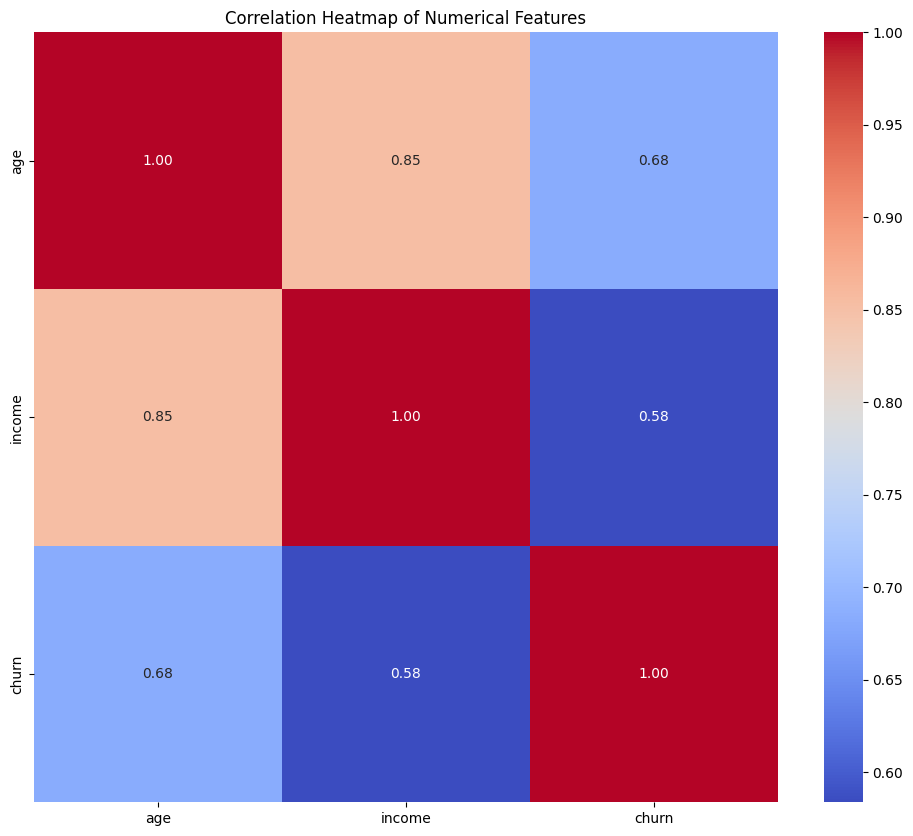


Displaying: target_distribution


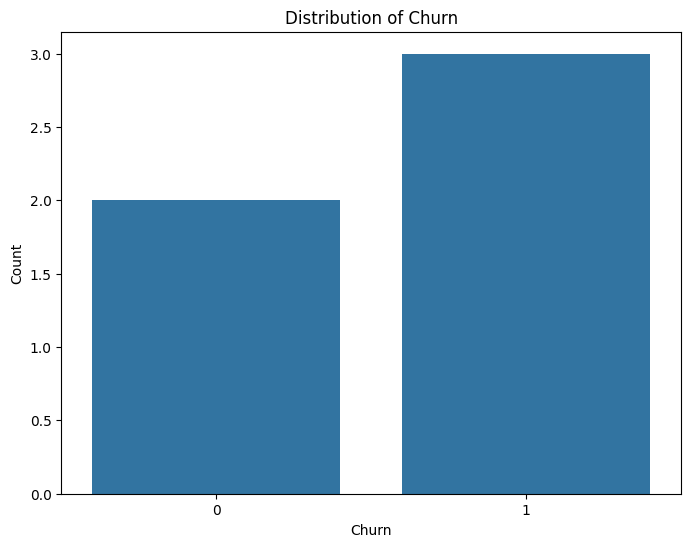

In [6]:
# Render the saved images directly in the notebook output
from IPython.display import Image, display

if "artifacts" in state and state["artifacts"]:
    for artifact_name, artifact_path in state["artifacts"].items():
        print(f"\nDisplaying: {artifact_name}")
        display(Image(filename=artifact_path))
else:
    print("No artifacts found.")